## Prithvi WxC Downscaling with ECCC Data: Model Finetuning

This notebook is a walk through fine tune the downscaling model 

We show how to initalize the model, load the pretrained `Prithvi WxC` weights, and finetune it

*Note to set up env run these commands in your terminal before running the notebook*

- `conda create -n wfm python=3.11 pip`
- `conda activate wfm`
- `pip install .[examples]` 
- `pip install -U git+https://github.com/NASA-IMPACT/Prithvi-WxC.git`
- `pip install -U git+https://github.com/IBM/granite-wxc.git`

In [ ]:
import logging
import warnings
logging.disable(logging.CRITICAL)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
import os
import torch
import wget
from torch.nn.parallel import DistributedDataParallel

from granitewxc.utils.config import get_config
from granitewxc.utils.distributed import init_ddp

from eccc_downscaling.utils.data import get_dataloaders_eccc
from eccc_downscaling.models.model import get_finetune_model_UNET
from eccc_downscaling.utils.plot import plot_sample, plot_loss

Configure the backends and torch states

In [3]:
torch.jit.enable_onednn_fusion(True)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = True

It is possible to use a cpu or gpu/s to generate inferences. Based on avaiablity of a `cuda:gpu`, we set the device that the model uses

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    use_gpu=True
else:
    device = torch.device('cpu')

We initialize the Distributed Data Parallel (DDP) environment to leverage multiple GPUs for training

In [5]:
os.environ["LOCAL_RANK"] = "0"
os.environ["RANK"] = "0"
os.environ["WORLD_SIZE"] = "1"
os.environ["MASTER_ADDR"] = "localhost"
os.environ["MASTER_PORT"] = "2468"

local_rank, rank = init_ddp(use_gpu=use_gpu)

### Load Config

We provide a configuration file to define data variables and model parameters

This includes variables to be downscaled, downscaling factor, model's dimensions, paths, ....

In [ ]:
config_path = './eccc_downscaling/config_UNET.yaml'
config = get_config(config_path)

### Dataloader

The JSON file maps unique indices (as string keys) to pairs of file paths. Each index key points to an array containing two strings:

````
{
  "index": [GDPS data path, HRDPS data path],
  ...
}
````

Each entry represents a paired dataset, where GDPS and HRDPS files correspond to the same timestamp or configuration and should be stored in NetCDF (.nc) format

In [7]:
train_dl, val_dl = get_dataloaders_eccc(config)

--> Training batches: 16
--> Validation batches: 16
--> Training samples: 16
--> Validation samples: 16


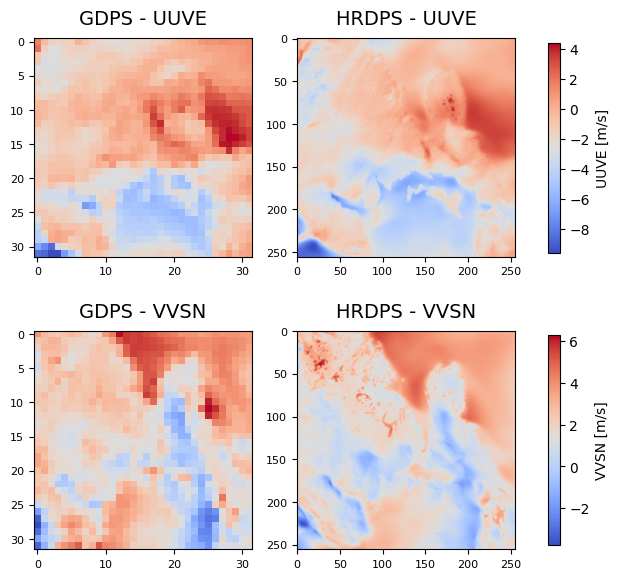

In [8]:
plot_sample(next(iter(train_dl)))

### Model Initialization

The model is built using the loaded configuration. To ensure compatibility with the provided weights during inference, the model configuration should remain consistent with the definitions in the configuration file

We provide **2** different model architectures `UNET` and `CONV` 

Both include:

- **Patch Embedding:** Extracts shallow features from the input data
- **Feature Extraction:** Utilizes the `Prithvi` backbone to extract features.

The key difference between the two is that the UNET-like version incorporates **static high-resolution data** into the model

In this notebook, we are using the UNET version

To switch to the `CONV` model, change the configuration to `config_CONV.yaml` and use the `get_finetune_model(config)` function

In [9]:
model = get_finetune_model_UNET(config)

Creating the model.
--> model has 254,648,712 params.


Let's add the Prithvi-WxC backbone pretrained weights

First download the weights from [Hugging Face](https://huggingface.co/Prithvi-WxC/prithvi.wxc.2300m.v1/tree/main) if you don't have it

In [10]:
# wget.download('https://huggingface.co/Prithvi-WxC/prithvi.wxc.2300m.v1/resolve/main/prithvi.wxc.2300m.v1.pt', out=config.path_backbone_weights)

Load the pretrained backbone

In [11]:
model.load_pretrained_backbone(
    weights_path = config.path_backbone_weights,
    sel_prefix=config.backbone_prefix,
    freeze = config.backbone_freeze,
)
model.to(device)
model = DistributedDataParallel(model, device_ids=[torch.cuda.current_device()], find_unused_parameters=True)

Loading pre-trained model weights ./experiments/pretrained/prithvi.wxc.2300m.v1.pt...


## Finetuning

The model is now ready for training

In [12]:
from torch.optim import AdamW
from torch.cuda.amp import GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR

from eccc_downscaling.utils.trainer import train_one_epoch, validate_one_epoch, save_checkpoint
from eccc_downscaling.models.loss import rmse_loss

## 
Defining the optimizer, scaler, and scheduler for the training process.

In [13]:
optimizer = AdamW(model.parameters(), lr=config.learning_rate)
scaler = GradScaler()
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=config.num_epochs * min(len(train_dl), config.limit_steps_train),
    eta_min=config.min_lr,
)

In this example notebook we are using only 1 data pair for training

Let's train it for a couple epochs

In [14]:
train_loss = []
val_loss = []

for epoch in range(config.num_epochs): 
    
    torch.distributed.barrier()

    print(f"learning_rate: {scheduler.get_last_lr()[0]}")

    print(f"rank {local_rank} start epoch ..")
    
    curr_train_loss, _ = train_one_epoch(
        model=model,
        local_rank=local_rank,
        train_loader=train_dl,
        optimizer=optimizer,
        loss_func=rmse_loss,
        epoch=epoch,
        scaler=scaler,
        scheduler=scheduler,
        gpu=use_gpu,
        limit_steps=config.limit_steps_train,
        num_epochs=config.num_epochs,
    )
    
    curr_val_loss, _ = validate_one_epoch(
        model=model,
        local_rank=local_rank,
        validation_loader=val_dl,
        loss_func=rmse_loss,
        epoch=epoch,
        gpu=use_gpu,
        limit_steps=config.limit_steps_valid,
    )

    train_loss.append(curr_train_loss.tolist())
    val_loss.append(curr_val_loss.tolist())

    if (epoch+1) % 5 == 0:
        save_checkpoint(
            config=config,
            scheduler=scheduler,
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            train_loss=train_loss,
            curr_val_loss=curr_val_loss,
        )

learning_rate: 1e-05
rank 0 start epoch ..


Training Epoch 1/5:   0%|                                             | 0/16 [00:00<?, ?batch/s]

[rank0]:[W220 15:16:31.994791809 reducer.cpp:1400] Warning: find_unused_parameters=True was specified in DDP constructor, but did not find any unused parameters in the forward pass. This flag results in an extra traversal of the autograd graph every iteration,  which can adversely affect performance. If your model indeed never has any unused parameters in the forward pass, consider turning this flag off. Note that this warning may be a false positive if your model has flow control causing later iterations to have unused parameters. (function operator())
Validation Epoch: 100%|███████████████████████████| 16/16 [00:01<00:00, 15.18batch/s, loss=3.57]


learning_rate: 9.140576474687267e-06
rank 0 start epoch ..


Validation Epoch: 100%|███████████████████████████| 16/16 [00:00<00:00, 18.10batch/s, loss=2.16]


...

learning_rate: 4.109423525312741e-06
rank 0 start epoch ..


Validation Epoch: 100%|███████████████████████████| 16/16 [00:00<00:00, 20.35batch/s, loss=1.42]


learning_rate: 1.8594235253127394e-06
rank 0 start epoch ..


Validation Epoch: 100%|███████████████████████████| 16/16 [00:00<00:00, 18.38batch/s, loss=1.34]


--> saved ./experiments/pretrained/checkpoint_4.pt


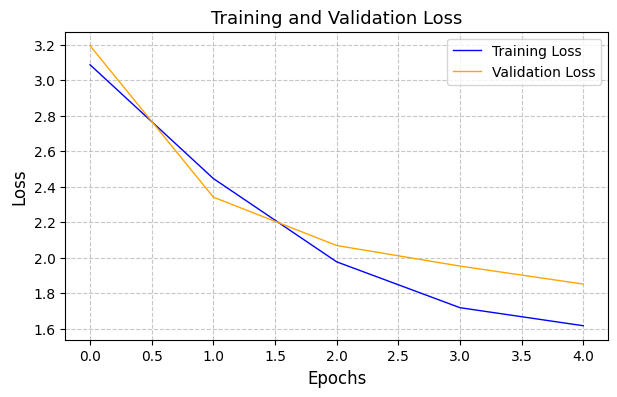

In [15]:
plot_loss(train_loss, val_loss)